# Lasso Regression

## Problem Statement

In this notebook, we will implement the Lasso Regression algorithm using Python.

Lasso Regression is a regularized version of Linear Regression that helps reduce overfitting and can automatically select important features by shrinking less important feature coefficients to zero.

## Dataset Used

We will use the Fish Market Dataset to predict the weight of a fish based on its physical measurements.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Dataset Loading

Now we will load the Diabetes dataset from Scikit-learn and convert it into a Pandas DataFrame.

In [3]:
data = {
    "Species": ["Bream","Bream","Roach","Pike","Smelt","Perch","Roach","Pike","Perch","Smelt"],
    "Length1":[23.2,24.0,20.0,30.0,12.2,18.4,19.0,32.0,21.0,13.0],
    "Length2":[25.4,26.3,22.0,32.5,13.4,20.0,21.0,34.0,23.0,14.2],
    "Length3":[30.0,31.2,24.0,35.0,14.5,22.5,23.5,37.0,25.0,15.3],
    "Height":[11.5,12.4,9.5,10.8,4.1,8.9,9.3,11.5,9.6,4.5],
    "Width":[4.02,4.30,3.60,4.80,2.00,3.80,3.90,5.00,4.10,2.10],
    "Weight":[242,290,120,390,12,110,130,450,150,15]
}

df = pd.DataFrame(data)

df.head()

,Species,Length1,Length2,Length3,Height,Width,Weight
0,Bream,23.2,25.4,30.0,11.5,4.02,242
1,Bream,24.0,26.3,31.2,12.4,4.30,290
2,Roach,20.0,22.0,24.0,9.5,3.60,120
3,Pike,30.0,32.5,35.0,10.8,4.80,390
4,Smelt,12.2,13.4,14.5,4.1,2.00,12


## Exploratory Data Analysis (EDA)

In this step, we will perform:

- Dataset Shape
- Missing Values
- Data Types
- Statistical Summary
- Correlation Analysis
- Data Visualization

In [4]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

df.describe()

Dataset Shape: (10, 7)

Missing Values:
Species    0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
Weight     0
dtype: int64

Data Types:
Species     object
Length1    float64
Length2    float64
Length3    float64
Height     float64
Width      float64
Weight       int64
dtype: object


,Length1,Length2,Length3,Height,Width,Weight
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.00000
mean,21.280000,23.180000,25.800000,9.210000,3.762000,190.90000
std,6.396666,6.759158,7.563656,2.825066,0.999664,148.73724
min,12.200000,13.400000,14.500000,4.100000,2.000000,12.00000
25%,18.550000,20.250000,22.750000,9.000000,3.650000,112.50000
50%,20.500000,22.500000,24.500000,9.550000,3.960000,140.00000
75%,23.800000,26.075000,30.900000,11.325000,4.250000,278.00000
max,32.000000,34.000000,37.000000,12.400000,5.000000,450.00000


In [6]:
df = pd.get_dummies(df, drop_first=True)

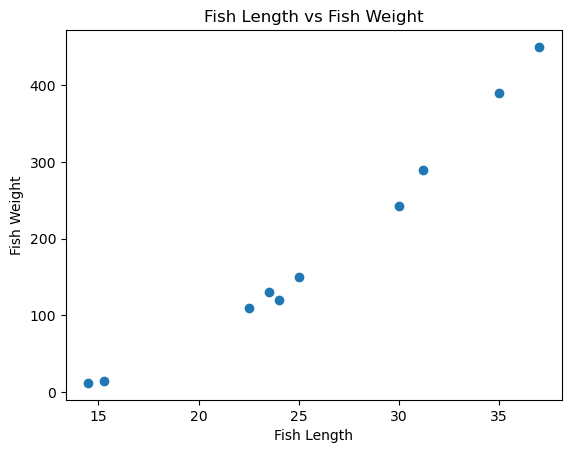

In [7]:
plt.scatter(df["Length3"], df["Weight"])
plt.xlabel("Fish Length")
plt.ylabel("Fish Weight")
plt.title("Fish Length vs Fish Weight")
plt.show()

## Data Preprocessing

In this dataset:

- No missing values
- All features are numerical
- Features are already standardized

Now we will separate input features and the target variable.

In [8]:
X = df.drop("Weight", axis=1)
y = df["Weight"]

X.head()

,Length1,Length2,Length3,Height,Width,Species_Perch,Species_Pike,Species_Roach,Species_Smelt
0,23.2,25.4,30.0,11.5,4.02,False,False,False,False
1,24.0,26.3,31.2,12.4,4.30,False,False,False,False
2,20.0,22.0,24.0,9.5,3.60,False,False,True,False
3,30.0,32.5,35.0,10.8,4.80,False,True,False,False
4,12.2,13.4,14.5,4.1,2.00,False,False,False,True


## Train-Test Split

The dataset is divided into:

- 80% Training Data
- 20% Testing Data

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (8, 9)
Testing Shape: (2, 9)


## Model Building

Now we will create the Lasso Regression model.

Alpha is the regularization parameter.

Higher alpha values increase regularization and remove less important features.

In [10]:
lasso_model = Lasso(alpha=0.1)

## Model Training

Now we will train the Lasso Regression model using the training dataset.

In [11]:
lasso_model.fit(X_train, y_train)

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.805e+02, tolerance: 1.872e+01
  model = cd_fast.enet_coordinate_descent(


,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


## Model Prediction

Now we will predict fish weight using the testing dataset.

In [12]:
y_pred = lasso_model.predict(X_test)

y_pred[:10]

array([167.19196536, 264.44813377])

## Model Evaluation

We will evaluate the model using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

In [13]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R² Score :", r2)

MAE : 21.37191579511557
MSE : 474.23077041611936
RMSE : 21.77684023030245
R² Score : 0.9032182101191593


## Result Interpretation

Lasso Regression reduces overfitting using L1 Regularization.

It can automatically remove less important features by assigning their coefficients to zero.

Higher R² and lower RMSE indicate better prediction of fish weight.

In [14]:
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

result.head(10)

,Actual,Predicted
8,150,167.191965
1,290,264.448134


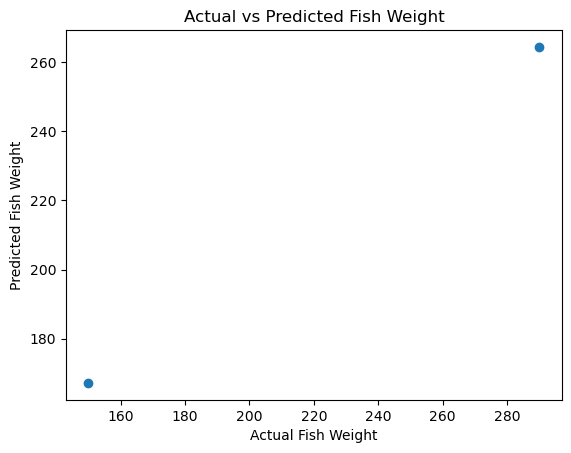

In [15]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Fish Weight")
plt.ylabel("Predicted Fish Weight")
plt.title("Actual vs Predicted Fish Weight")

plt.show()

## Conclusion

In this notebook, we successfully implemented the Lasso Regression algorithm.

The following steps were completed:

- Dataset Loading
- Exploratory Data Analysis
- Data Preprocessing
- Train-Test Split
- Model Building
- Model Training
- Model Prediction
- Model Evaluation
- Result Interpretation

Lasso Regression is useful for predicting continuous values while automatically selecting the most important features. It is widely used in applications such as agriculture, biology, healthcare, and finance.